## Build my first agent that connects with multiple tools
### Buil my first set of tools where each tool is an API to perform specific task. Tools acts as a brain for LLM to provide additional context

In [1]:
import os
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
model = ChatGroq(model="openai/gpt-oss-120b")

In [2]:
# Tavily search AI tool integration
from langchain_tavily import TavilySearch

tool_search = TavilySearch(
    max_results=3,
    topic="general",
    # include_answer=False,
    # include_raw_content=False,
    # include_images=False,
    # include_image_descriptions=False,
    # search_depth="basic",
    # time_range="day",
    # include_domains=None,
    # exclude_domains=None
)

#testing tool1
tool_search.invoke("What is groq trained on?")


{'query': 'What is groq trained on?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.eesel.ai/blog/groq',
   'title': 'What is Groq? The AI chip maker explained (2026)',
   'content': 'While many companies in the AI world are focused on building bigger and more complex models, Groq is tackling a different, equally important problem: speed. Groq\'s goal is to make AI inference incredibly fast and affordable, which could open the door to a whole new wave of real-time AI tools. Think of it this way: while Groq might be the Formula 1 engine you use for speed, a platform like eesel AI is the car itself. Groq is an American AI chip company that specializes in building hardware for extremely fast AI inference. Groq is most beneficial for applications requiring real-time AI responses, such as interactive customer support, live data analysis in critical fields like finance, and fluid AI-powered creative tools. Groq is an AI chip company focused o

In [3]:
# Calculator.AI.tool.integration
from langchain.tools import tool
#decorator @ helps initialize my custom tool so model understands this is a tool
@tool("calculator", description="Performs arithmetic calculations. Use this for any math problems.")
def tool_calc(expression: str) -> str:
    """Evaluate mathematical expressions."""
    return str(eval(expression))

tool
#tool.invoke("what is 2 to the power 32?")

<function langchain_core.tools.convert.tool(name_or_callable: str | collections.abc.Callable | None = None, runnable: langchain_core.runnables.base.Runnable | None = None, *args: Any, description: str | None = None, return_direct: bool = False, args_schema: type[pydantic.main.BaseModel] | dict[str, typing.Any] | None = None, infer_schema: bool = True, response_format: Literal['content', 'content_and_artifact'] = 'content', parse_docstring: bool = False, error_on_invalid_docstring: bool = True, extras: dict[str, typing.Any] | None = None) -> langchain_core.tools.base.BaseTool | collections.abc.Callable[[collections.abc.Callable | langchain_core.runnables.base.Runnable], langchain_core.tools.base.BaseTool]>

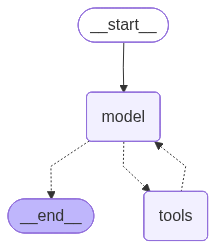

In [4]:
# Create Agent
from langchain.agents import create_agent

agent=create_agent(
    model=model, tools=[tool_search,tool_calc] 
)

agent

In [5]:
# create user prompt
user_input = "Calculate 1.2*100000? and then share the current tax rate for an income of 100000 with 20 percent bonus?"

for question in agent.stream(
    {"messages": user_input},
    stream_mode="values"
):
    question["messages"][-1].pretty_print()

================================ Human Message =================================

Calculate 1.2*100000? and then share the current tax rate for an income of 100000 with 20 percent bonus?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_75547e53-aceb-4d96-aca8-6799aae991b8)
 Call ID: fc_75547e53-aceb-4d96-aca8-6799aae991b8
  Args:
    query: 2024 federal income tax rate for $120,000 income
    search_depth: advanced
    time_range: year
================================= Tool Message =================================
Name: tavily_search

{"query": "2024 federal income tax rate for $120,000 income", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://cdn.prod.website-files.com/6804495aa7249cb757abdd6f/687608cb88cadff556e5f6c9_dutuwiwe.pdf", "title": "[PDF] 2024 Federal Income Tax Rates and Thresholds", "content": "The foreign-earned income exclusion amount will increase to $126,500 in 2024,